In [2]:
import numpy as np
import pandas as pd
import os
from collections import defaultdict
from shutil import copy
from shutil import copytree, rmtree

import tensorflow as tf
import matplotlib.pyplot as plt


In [2]:
print(tf.__version__)

2.15.0


Dataset Loading

Preperation of Data - 

Training Data

In [3]:
train_df = pd.read_csv('meta\\train.txt', header = None, names=['path'])
train_df['path'] = train_df['path'].apply(lambda x: x.replace('/', '\\') )

train_df.head()

,path
0,apple_pie\1005649
1,apple_pie\1014775
2,apple_pie\1026328
3,apple_pie\1028787
4,apple_pie\1043283


In [4]:
test_df = pd.read_csv('meta\\test.txt', header = None, names=['path'])

test_df['path'] = test_df['path'].apply(lambda x: x.replace('/', '\\') )
test_df.head()


,path
0,apple_pie\1011328
1,apple_pie\101251
2,apple_pie\1034399
3,apple_pie\103801
4,apple_pie\1038694


In [5]:
def spliter(data, class_or_id='id'):
    if class_or_id.upper() == 'CLASS':
        output = data.split('\\')[0]
        
    else:
        output = data.split('\\')[-1]
    return output

In [6]:
train_df['label'] = train_df['path'].map(lambda x: spliter(data = x, class_or_id = 'Class')) 
train_df.head()

,path,label
0,apple_pie\1005649,apple_pie
1,apple_pie\1014775,apple_pie
2,apple_pie\1026328,apple_pie
3,apple_pie\1028787,apple_pie
4,apple_pie\1043283,apple_pie


In [7]:
train_df['idx'] = train_df['path'].map(lambda x: spliter(x)) 
train_df.head()

,path,label,idx
0,apple_pie\1005649,apple_pie,1005649
1,apple_pie\1014775,apple_pie,1014775
2,apple_pie\1026328,apple_pie,1026328
3,apple_pie\1028787,apple_pie,1028787
4,apple_pie\1043283,apple_pie,1043283


In [8]:
test_df['label'] = test_df['path'].map(lambda x: spliter(x, 'class')) 
test_df['idx'] = test_df['path'].map(lambda x: spliter(x)) 
test_df.head()

,path,label,idx
0,apple_pie\1011328,apple_pie,1011328
1,apple_pie\101251,apple_pie,101251
2,apple_pie\1034399,apple_pie,1034399
3,apple_pie\103801,apple_pie,103801
4,apple_pie\1038694,apple_pie,1038694


In [9]:
mini_20 = train_df['label'].unique()[:20]
mini_20 = [f.upper() for f in mini_20]
mini_20

['APPLE_PIE',
 'BABY_BACK_RIBS',
 'BAKLAVA',
 'BEEF_CARPACCIO',
 'BEEF_TARTARE',
 'BEET_SALAD',
 'BEIGNETS',
 'BIBIMBAP',
 'BREAD_PUDDING',
 'BREAKFAST_BURRITO',
 'BRUSCHETTA',
 'CAESAR_SALAD',
 'CANNOLI',
 'CAPRESE_SALAD',
 'CARROT_CAKE',
 'CEVICHE',
 'CHEESECAKE',
 'CHEESE_PLATE',
 'CHICKEN_CURRY',
 'CHICKEN_QUESADILLA']

In [10]:
def prepare_data(label):
    if label.upper() in mini_20:
        return label
    else:
        return 'Others'

In [11]:
train_df['label'] = train_df['label'].map(lambda x: prepare_data(x))
test_df['label'] = test_df['label'].map(lambda x: prepare_data(x))

In [12]:
train_df['label'].unique()


array(['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio',
       'beef_tartare', 'beet_salad', 'beignets', 'bibimbap',
       'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad',
       'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheesecake',
       'cheese_plate', 'chicken_curry', 'chicken_quesadilla', 'Others'],
      dtype=object)

In [13]:
def add_exact_path(path):
    return 'images\\'+path+'.jpg'

In [14]:
train_df['path'] = train_df[['path']].apply(add_exact_path, axis=1)
test_df['path'] = test_df[['path']].apply(add_exact_path, axis=1)
train_df.head()

,path,label,idx
0,images\apple_pie\1005649.jpg,apple_pie,1005649
1,images\apple_pie\1014775.jpg,apple_pie,1014775
2,images\apple_pie\1026328.jpg,apple_pie,1026328
3,images\apple_pie\1028787.jpg,apple_pie,1028787
4,images\apple_pie\1043283.jpg,apple_pie,1043283


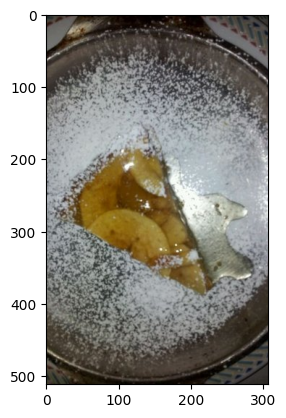

In [15]:
from matplotlib import pyplot as plt
img = plt.imread(train_df['path'].iloc[0])
plt.imshow(img)

In [16]:
img.shape

(512, 308, 3)

In [17]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )
test_gen = ImageDataGenerator(rescale=1./255)

In [18]:

train_gen = datagen.flow_from_dataframe(dataframe = train_df, directory=None, x_col='path', y_col='label',
    weight_col=None, target_size=(256, 256), color_mode='rgb',
    classes=None, class_mode='categorical', batch_size=32, shuffle=True)

Found 75750 validated image filenames belonging to 21 classes.


In [19]:
test_gen = test_gen.flow_from_dataframe(dataframe = test_df, directory=None, x_col='path', y_col='label',
    weight_col=None, target_size=(256, 256), color_mode='rgb',
    classes=None, class_mode='categorical', batch_size=32, shuffle=True)

Found 25250 validated image filenames belonging to 21 classes.


In [20]:
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import regularizers
from tensorflow.keras.applications import efficientnet
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Convolution2D, MaxPooling2D, ZeroPadding2D, GlobalAveragePooling2D, AveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications.xception import Xception

Xception = Xception(weights='imagenet', include_top=False)
x = Xception.output
x = GlobalAveragePooling2D()(x)
x = Dense(256,activation='relu')(x)
# x = Dropout(0.4)(x)
x = Dense(128,activation='relu')(x)
x = Dropout(0.2)(x)

predictions = Dense(21, activation='softmax')(x)

model = Model(inputs=Xception.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])



In [21]:
history = model.fit(train_gen,
                              steps_per_epoch = len(train_gen) // 32,
                    epochs=60,
                    verbose=2)

Epoch 1/60


74/74 - 1239s - loss: 1.2955 - accuracy: 0.7901 - 1239s/epoch - 17s/step
Epoch 2/60
74/74 - 1216s - loss: 1.0865 - accuracy: 0.7935 - 1216s/epoch - 16s/step
Epoch 3/60
74/74 - 1182s - loss: 0.9967 - accuracy: 0.7986 - 1182s/epoch - 16s/step
Epoch 4/60
74/74 - 1183s - loss: 0.8839 - accuracy: 0.8066 - 1183s/epoch - 16s/step
Epoch 5/60
74/74 - 1166s - loss: 0.8190 - accuracy: 0.8130 - 1166s/epoch - 16s/step
Epoch 6/60
74/74 - 1176s - loss: 0.7728 - accuracy: 0.8180 - 1176s/epoch - 16s/step
Epoch 7/60
74/74 - 1172s - loss: 0.7298 - accuracy: 0.8197 - 1172s/epoch - 16s/step
Epoch 8/60
74/74 - 1175s - loss: 0.5915 - accuracy: 0.8484 - 1175s/epoch - 16s/step
Epoch 9/60
74/74 - 1172s - loss: 0.6267 - accuracy: 0.8374 - 1172s/epoch - 16s/step
Epoch 10/60
74/74 - 1197s - loss: 0.6102 - accuracy: 0.8399 - 1197s/epoch - 16s/step
Epoch 11/60
74/74 - 1190s - loss: 0.5490 - accuracy: 0.8522 - 1190s/epoch - 16s/step
Epoch 12/60
74/74 - 1182s - loss: 0.5203 - accuracy: 0.8539 - 1182s/epoc

In [22]:
result = model.evaluate(test_gen, batch_size=32)
print(result)

790/790 [==============================] - 2756s 3s/step - loss: 0.3506 - accuracy: 0.8994
[0.35063791275024414, 0.8993663191795349]


dict_keys(['loss', 'accuracy'])


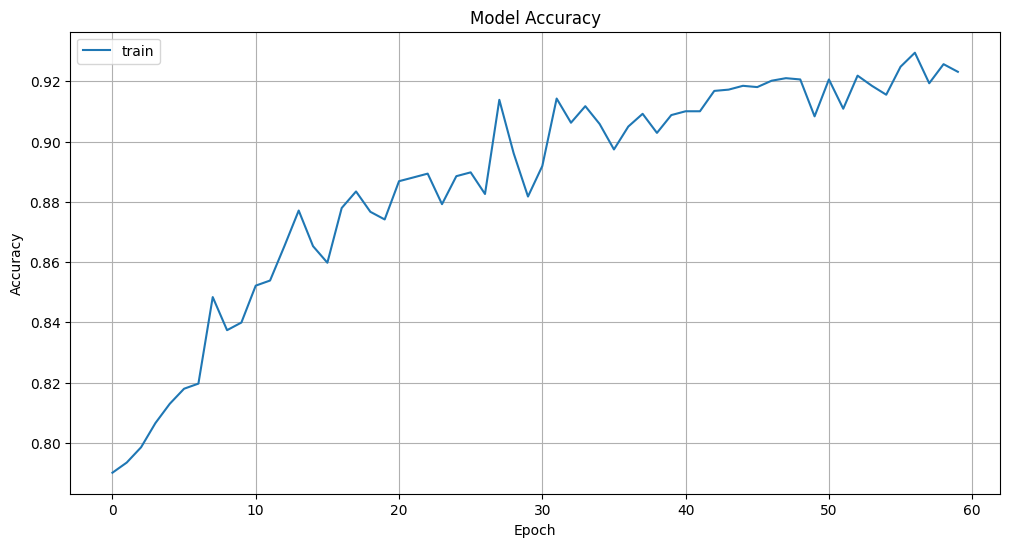

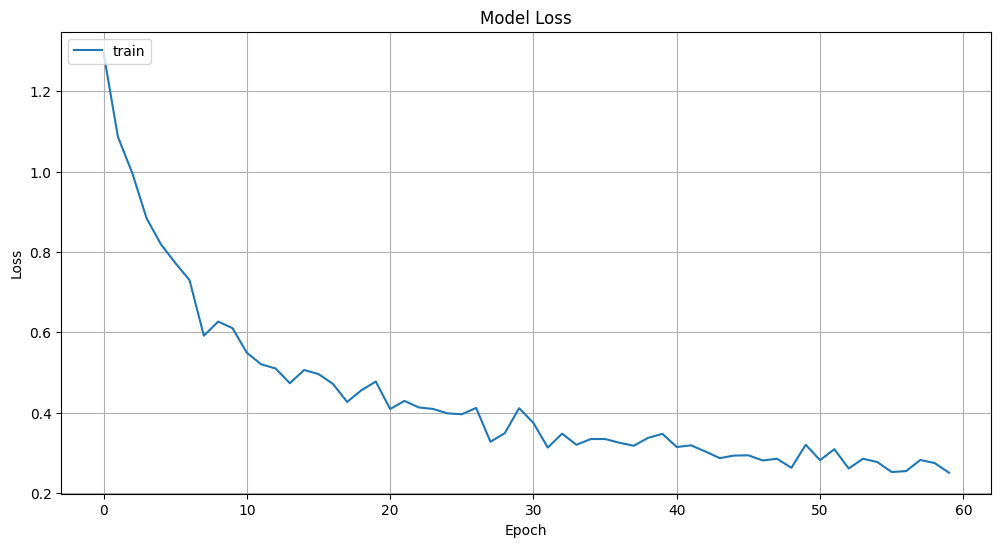

In [25]:
import matplotlib.pyplot as plt

# Print the keys in the history dictionary
print(history.history.keys())

# Check if validation accuracy and loss are present in the history
val_accuracy_present = 'val_accuracy' in history.history
val_loss_present = 'val_loss' in history.history

# Plot model accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='train')
if val_accuracy_present:
    plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# Plot model loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='train')
if val_loss_present:
    plt.plot(history.history['val_loss'], label='validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


In [26]:
model.save('food21.hdf5', save_format='h5')

c:\Users\ishfa tech\miniconda3\envs\fyp\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [27]:
model.save('food21.keras')